# Trading Strategy Notebook

This notebook explores the historical market data for TOMATOES and EMERALDS
and sketches a simple rule-based trading strategy.


In [1]:
import pandas as pd
from pathlib import Path

data_path = Path(".")

prices_m2 = pd.read_csv(data_path / "prices_round_0_day_-2.csv", sep=";")
prices_m1 = pd.read_csv(data_path / "prices_round_0_day_-1.csv", sep=";")
trades_m2 = pd.read_csv(data_path / "trades_round_0_day_-2.csv", sep=";")
trades_m1 = pd.read_csv(data_path / "trades_round_0_day_-1.csv", sep=";")

prices_m2.head(), prices_m1.head(), trades_m2.head(), trades_m1.head()


(   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  \
 0   -2          0  EMERALDS         9992            11         9990   
 1   -2          0  TOMATOES         4993             7         4992   
 2   -2        100  TOMATOES         4998             5         4993   
 3   -2        100  EMERALDS         9992            15         9990   
 4   -2        200  TOMATOES         4994             6         4993   
 
    bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
 0            25          NaN           NaN        10008            11   
 1            17          NaN           NaN         5007             7   
 2             7       4992.0          16.0         5007             7   
 3            20          NaN           NaN        10008            15   
 4            20          NaN           NaN         5008             6   
 
    ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
 0        10010            25          NaN       

In [2]:
# Basic per-product summary of mid prices
def price_summary(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("product")["mid_price"]
    summary = pd.DataFrame({
        "mid_min": grouped.min(),
        "mid_mean": grouped.mean(),
        "mid_max": grouped.max(),
        "n_rows": grouped.size(),
    })
    return summary

print("=== DAY -2 PRICE SUMMARY ===")
display(price_summary(prices_m2))
print("\n=== DAY -1 PRICE SUMMARY ===")
display(price_summary(prices_m1))


=== DAY -2 PRICE SUMMARY ===


,mid_min,mid_mean,mid_max,n_rows
product,,,,
EMERALDS,9996.0,9999.9972,10004.0,10000
TOMATOES,4988.0,5007.9485,5036.0,10000



=== DAY -1 PRICE SUMMARY ===


,mid_min,mid_mean,mid_max,n_rows
product,,,,
EMERALDS,9996.0,9999.99800,10004.0,10000
TOMATOES,4946.5,4977.56775,5011.0,10000


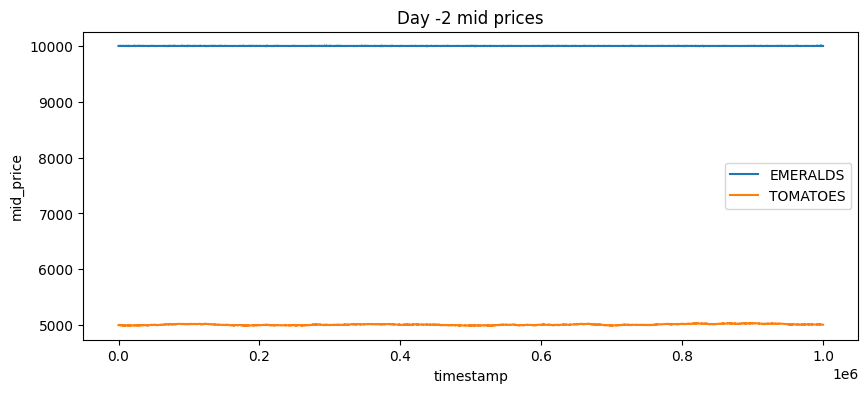

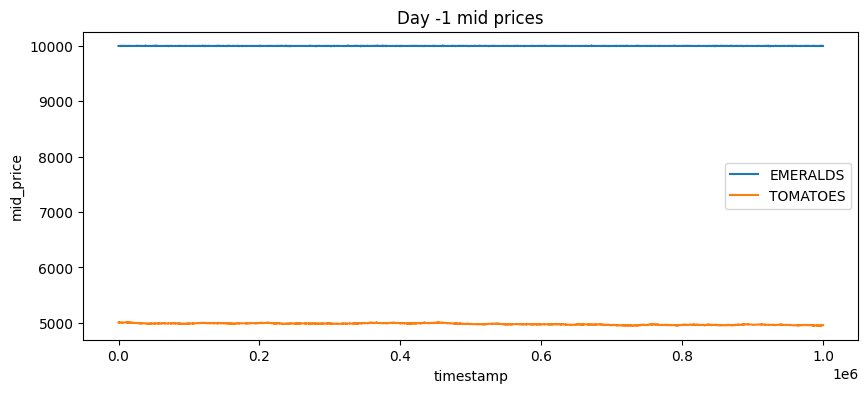

In [3]:
# Optional: visualize mid prices over time for each product
import matplotlib.pyplot as plt

def plot_mid_prices(df: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(10, 4))
    for product, g in df.groupby("product"):
        ax.plot(g["timestamp"], g["mid_price"], label=product)
    ax.set_title(title)
    ax.set_xlabel("timestamp")
    ax.set_ylabel("mid_price")
    ax.legend()
    plt.show()

plot_mid_prices(prices_m2, "Day -2 mid prices")
plot_mid_prices(prices_m1, "Day -1 mid prices")


## Strategy idea (first draft)

From the summaries and plots, we can start to design a simple rule-based strategy.

A typical starting point is a **mean-reversion** strategy on TOMATOES:

- Compute a rolling average of TOMATOES mid price.
- If current mid is sufficiently below the rolling average, we consider it "cheap" and buy a small quantity.
- If current mid is sufficiently above the rolling average, we consider it "expensive" and sell (or reduce a long position).
- Always respect inventory limits (e.g., maximum long/short units).

EMERALDS looks much more stable, so we might trade it less aggressively or not at all in the first version.


In [4]:
# Sketch of a simple mean-reversion rule on TOMATOES (offline backtest-style)
def simple_tomato_signals(prices: pd.DataFrame, window: int = 20, threshold: float = 1.0):
    df = prices[prices["product"] == "TOMATOES"].copy()
    df = df.sort_values("timestamp")
    df["rolling_mean"] = df["mid_price"].rolling(window=window, min_periods=window).mean()
    df["diff"] = df["mid_price"] - df["rolling_mean"]
    # Signal: +1 = buy, -1 = sell, 0 = do nothing
    df["signal"] = 0
    df.loc[df["diff"] < -threshold, "signal"] = 1
    df.loc[df["diff"] > threshold, "signal"] = -1
    return df[["day", "timestamp", "product", "mid_price", "rolling_mean", "diff", "signal"]]

signals_m2 = simple_tomato_signals(prices_m2)
signals_m1 = simple_tomato_signals(prices_m1)
signals_m2.head(), signals_m1.head()


(   day  timestamp   product  mid_price  rolling_mean  diff  signal
 1   -2          0  TOMATOES     5000.0           NaN   NaN       0
 2   -2        100  TOMATOES     5002.5           NaN   NaN       0
 4   -2        200  TOMATOES     5001.0           NaN   NaN       0
 7   -2        300  TOMATOES     5001.5           NaN   NaN       0
 9   -2        400  TOMATOES     5001.5           NaN   NaN       0,
    day  timestamp   product  mid_price  rolling_mean  diff  signal
 0   -1          0  TOMATOES     5006.0           NaN   NaN       0
 3   -1        100  TOMATOES     5006.5           NaN   NaN       0
 5   -1        200  TOMATOES     5006.5           NaN   NaN       0
 6   -1        300  TOMATOES     5007.0           NaN   NaN       0
 8   -1        400  TOMATOES     5007.0           NaN   NaN       0)